In [449]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Data 

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [450]:
df_DA_US = df[(df['job_title'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

In [451]:
df_DA_US['job_posted_month_no'] = df_DA_US['job_posted_date'].dt.month

In [452]:
df_DA_US_explode = df_DA_US.explode('job_skills')

In [453]:

df_DA_US_pivot = df_DA_US_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)

df_DA_US_pivot.loc['Total'] = df_DA_US_pivot.sum()

df_DA_US_pivot = df_DA_US_pivot[df_DA_US_pivot.loc['Total'].sort_values(ascending=False).index]
df_DA_US_pivot = df_DA_US_pivot.drop('Total')

In [454]:

DA_totals = df_DA_US.groupby('job_posted_month_no').size()

In [455]:

df_DA_US_percent = df_DA_US_pivot.div(DA_totals/100, axis=0)

In [456]:

df_DA_US_percent = df_DA_US_percent.reset_index()
df_DA_US_percent = df_DA_US_percent.set_index('job_posted_month_no')

df_DA_US_percent.head()

job_skills,sql,excel,tableau,python,power bi,sas,r,word,powerpoint,oracle,...,flutter,tidyr,theano,elixir,electron,chainer,symphony,svelte,sqlserver,next.js
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,62.665198,43.006608,35.572687,29.129956,17.951542,21.696035,18.612335,9.306167,9.691630,9.030837,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,60.903427,42.367601,31.775701,29.439252,23.520249,21.028037,18.146417,9.968847,10.124611,7.710280,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,58.883994,42.584435,33.994126,29.368576,20.337739,22.026432,17.694567,10.425844,9.324523,7.856094,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,61.723886,42.147553,33.747261,30.752374,21.329438,18.845873,17.384953,10.445581,9.715121,8.911614,...,0.073046,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,61.072664,42.387543,31.747405,29.065744,21.712803,17.820069,18.944637,7.958478,10.294118,8.477509,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


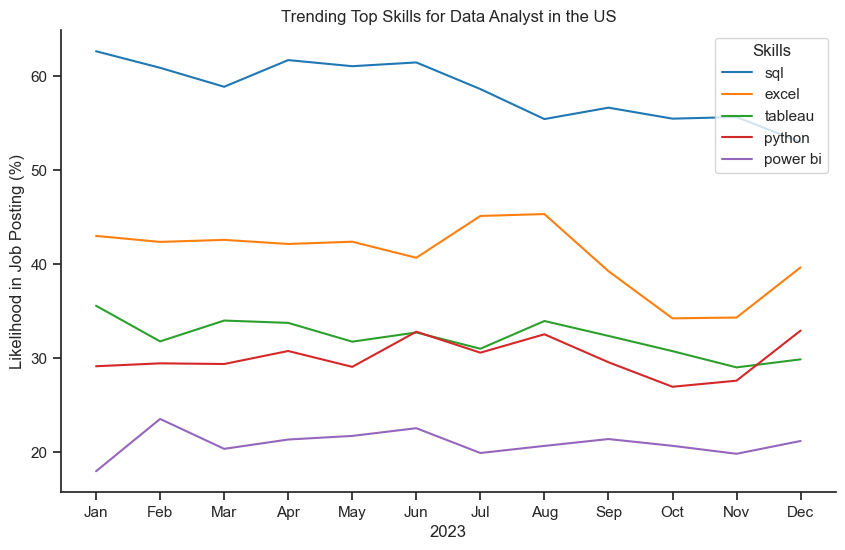

In [457]:
top_skills = df_DA_US_percent.sum().sort_values(ascending=False).head(5).index
df_plot = df_DA_US_percent[top_skills]

sns.set_theme(style='ticks')
plt.figure(figsize=(10,6))
sns.lineplot(data=df_plot, dashes=False, palette='tab10')

plt.title('Trending Top Skills for Data Analyst in the US')
plt.ylabel('Likelihood in Job Posting (%)')
plt.xlabel('2023')

# Convert month numbers to abbreviated names
month_labels = [pd.to_datetime(str(i), format='%m').strftime('%b') for i in range(1, 13)]
plt.xticks(ticks=range(1,13), labels=month_labels)

sns.despine()
plt.legend(title='Skills')
plt.show()